# Capítulo 6 - O Gêmeo Digital

Esse capítulo tem como principal foco testar as propriedades do Gêmeo Digital completo. Nós realizamos uma análise da probabilidade de falha do sistema hidráulico isolado em relação a vazão e do Gêmeo como um todo em relação da energia dissipada utilizando o método de Monte Carlo. Após isso, foi feito a aproximação do comportamento da potência ao decorrer do tempo utilizando pontos discretos como base e o método de interpolação linear e cúbica, também junto da regressão polinomial para determinar a curva correspondente da função. A sensibilidade das saídas em relação aos parâmetros de temperatura e largura do canal também foi analisada, e por fim, utilizamos o método iterativo de Newton-Raphson para aproximar o valor ótimo da largura do canal para uma determinada limitação de energia no sistema. 

In [1]:
# Importações!!!

import sys
import os
import importlib

root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if root not in sys.path:
    sys.path.insert(0, root)

import data_structures
importlib.reload(data_structures)
import analise_falhas
importlib.reload(analise_falhas)
import P2_PARTE_3_GD
importlib.reload(P2_PARTE_3_GD)
import sensitivity_analysis
importlib.reload(sensitivity_analysis)
import env
importlib.reload(env)
config = env.CONFIG_FALHAS
config_mh = env.CONFIG_MH

#### Probabilidade de falha do sistema hidráulico através do método de Monte Carlo

O intuito dessa seção é utilizar o método numérico de Monte Carlo para estimar a probabilidade de que, após um período arbitrário de desgaste dos micro canais que compõem a rede hidráulica, haverá a perda de funcionalidade do sistema, determinado por um limite crítico de vazão de entrada ($Y_{\text{critico}}=1.25 × 10−5$). Para isso, iremos modelar a situação individual de cada canal como uma variável aleatória de Bernoulli $X_i$, onde 1 representa um canal obstruído e 0 representa um canal funcional.  Assim, vamos assumir uma probabilidade de falha $p_O$ e um fator de escala de obstrução $f_{\text{obs}}$, usando essa probabilidade , nós geramos um número aleatório entre 0 e 1 para todos os canais, que são considerados como obstruídos caso seu número gerado seja menor que $p_O$. 

Com isso, a condutância hidráulica de cada canal depende do fator $f_{\text{obs}}$ e se torna tal:

$$C_i(X_i) = \begin{cases} C_{\text{i original}} & \text{se } X_i = 0 \\ \frac{C_{\text{i original}}}{f_{\text{obs}}} & \text{se } X_i = 1 \end{cases}$$

Através do novo vetor de condutâncias, a matriz global é reconstruída e solucionada de forma convencional para determinar a vazão $q_{\text{inlet}}$ do sistema sob essa configuração. Agora, o método de Monte Carlo é necessário para solucionar o problema de determinar a probabilidade de que o $q_{\text{inlet}}$ esteja dentro do limite crítico, sem que seja necessário calcular todas as permutações possíveis de canais com condição $X = 1$ ou $X = 0$.

#### Método de Monte Carlo

O método de Monte Carlo consiste de um algoritmo que utiliza uma grande quantidade de permutações de entradas aleatórias, dependentes de probabilidades preestabelecidas, para aproximar um resultado numérico. No nosso caso, o vetor aleatório de canais obstruídos constitui as entradas, enquanto o resultado que queremos aproximar é a probabilidade $\mathbb{P}$ de falha do sistema, que seria obtida analiticamente por: 
$$\mathbb{P} = \mathbb{E}[I(X)]$$

Onde $I(X)$ é uma função de indicação, $I(X) = \begin{cases} 1 & \text{se } q_{\text{inlet}}(X) < Y_{\text{critico}}\\ 0 & \text{se } q_{\text{inlet}}(X) \ge Y_{\text{critico}} \end{cases}$ , que define a falha $(1)$ ou sucesso $(0)$ do sistema de acordo com o $q_{\text{inlet}}$ calculado de forma convencional.
Como calcular $\mathbb{E}[I(X)]$ com a quantidade de possibilidades de $X$ do nosso problema é computacionalmente inviável, o método de Monte Carlo reduz a complexidade da solução calculando apenas $N$ vezes $I(X)$ para $N$ permutações do vetor $X$, criando um espaço amostral suficientemente grande para $\mathbb{P}$, determinado por:
$$\mathbb{P} \approx \frac{1}{N} \sum_{n=1}^{N} I(X^{(n)})$$

=== CALIBRANDO PONTO DE OPERAÇÃO OPERACIONAL ===
Pressão calibrada para o ensaio:       87584.77 Pa
Vazão calculada para a rede sem falhas: 2.00000e-05 m³/s
Limite crítico de falha do enunciado:  1.25000e-05 m³/s
A rede limpa falha? False
Disparando loops estocásticos de Monte Carlo
Rodando convergencia assintotica de Monte Carlo (N=4000) para p_O=0.35 e f_obs=5


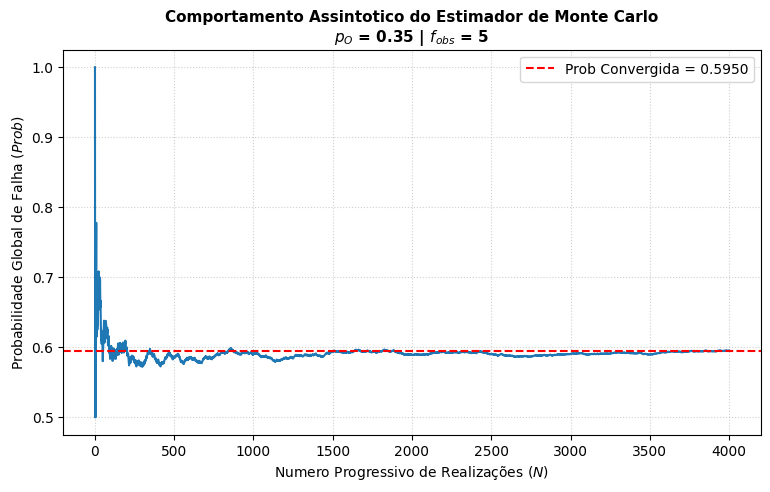


Iniciando Varredura do Domínio de Falhas Individuais...
Analisando fator de severidade de obstrução: f_obs = 5
  p_O = 0.05 -> Prob Global de Falha = 0.1013
  p_O = 0.10 -> Prob Global de Falha = 0.1807
  p_O = 0.15 -> Prob Global de Falha = 0.2780
  p_O = 0.20 -> Prob Global de Falha = 0.3578
  p_O = 0.25 -> Prob Global de Falha = 0.4462
  p_O = 0.30 -> Prob Global de Falha = 0.5130
  p_O = 0.35 -> Prob Global de Falha = 0.5705
  p_O = 0.40 -> Prob Global de Falha = 0.6368
  p_O = 0.45 -> Prob Global de Falha = 0.6903
  p_O = 0.50 -> Prob Global de Falha = 0.7468
  p_O = 0.55 -> Prob Global de Falha = 0.8083
  p_O = 0.60 -> Prob Global de Falha = 0.8605
  p_O = 0.65 -> Prob Global de Falha = 0.9200
Analisando fator de severidade de obstrução: f_obs = 10
  p_O = 0.05 -> Prob Global de Falha = 0.0980
  p_O = 0.10 -> Prob Global de Falha = 0.2035
  p_O = 0.15 -> Prob Global de Falha = 0.2752
  p_O = 0.20 -> Prob Global de Falha = 0.3715
  p_O = 0.25 -> Prob Global de Falha = 0.4363
  p_

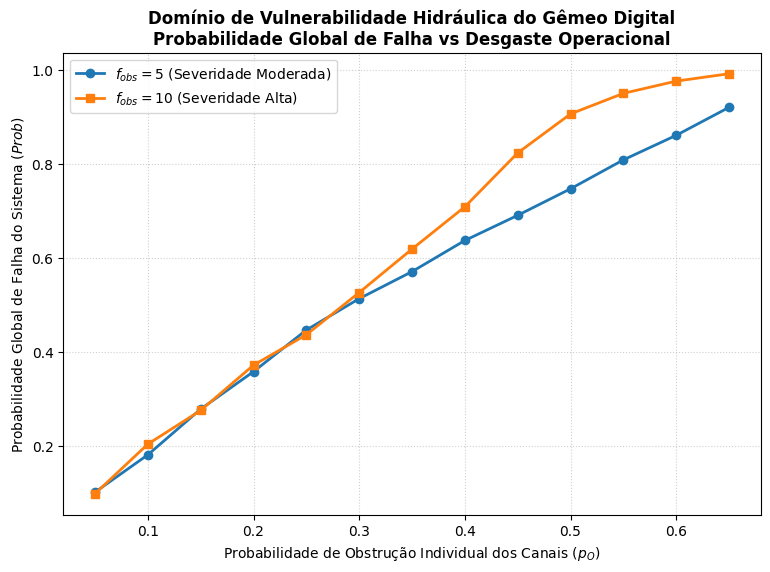

In [7]:
Xno, conec = data_structures.GeraGrafo(env.CONFIG_FALHAS["LEVELS"]);
Xno = Xno * 0.001

print("=== CALIBRANDO PONTO DE OPERAÇÃO OPERACIONAL ===")
config["INLET_PRESSURE"] = 1.0e4 
vazao_teste = analise_falhas.resolver_vazao_estacionaria(conec, Xno, config, C_estocastico=None)

fator_pressao = 2.0e-5 / vazao_teste
config["INLET_PRESSURE"] = 1.0e4 * fator_pressao

vazao_limpa = analise_falhas.resolver_vazao_estacionaria(conec, Xno, config, C_estocastico=None)
print(f"Pressão calibrada para o ensaio:       {config['INLET_PRESSURE']:.2f} Pa")
print(f"Vazão calculada para a rede sem falhas: {vazao_limpa:.5e} m³/s")
print(f"Limite crítico de falha do enunciado:  {config['V_CRITIC']:.5e} m³/s")
print(f"A rede limpa falha? {vazao_limpa < config['V_CRITIC']}")

print("Disparando loops estocásticos de Monte Carlo")
N_convergido = analise_falhas.avaliar_convergencia_monte_carlo(conec, Xno, config, p_O=0.35, f_obs=5, N_max=4000)
analise_falhas.varredura_probabilidade_individual(conec, Xno, config, N_estatistico=N_convergido)


##### Probabilidade de falha do sistema acoplado completo em relação a energia

Agora, será determinada a probabilidade de falha do sistema com acoplamento forte entre a rede hidráulica, placa térmica e membrana elástica, com relação ao critério de energia dissipida $E$, nesse caso $E < 7$. O método se mantém bem similar em relação a situação anterior, nós iremos utilizar o método de Monte Carlo novamente, e novamente vamos gerar um vetor $X$ aleatório de falhas de acordo com a probabilidade $p_O$  e resolver o sistema pelos métodos convencionais para encontrar uma permutação de resultado, a maior diferença em relação a situação anterior é que agora devemos utilizar o funcional $E$, que depende do intervalo de variação do tempo $dt$, determinado como: 
$$ E  = \int_{t_i}^{t_f} \mathcal{P}(t)\, dt $$

onde: $$\mathcal{P}(t)=p^T(t)\mathbb{A} p(t)$$

Assim, definimos outra função indicadora tal que:

$$ I(X) = \begin{cases} 1 & \text{se } E(X) < 7.0 \\ 0 & \text{se } E(X) \ge 7.0 \end{cases} $$

Adiante o processo se torna idêntico ao anterior, iremos utilizar a lógica do método de Monte Carlo para encontrar um resultado númerico aproximado a probabilidade $\mathbb{P}$, da forma:

$$ \mathbb{P} = \mathbb{E}[I(X)] \approx \frac{1}{N} \sum_{n=1}^{N} I(X^{(n)}) $$


Iniciando análise dinâmica do Gêmeo Digital Completo...
Analisando passo de tempo dt = 0.05
  100/2000 realizações concluídas
  200/2000 realizações concluídas
  300/2000 realizações concluídas
  400/2000 realizações concluídas
  500/2000 realizações concluídas
  600/2000 realizações concluídas
  700/2000 realizações concluídas
  800/2000 realizações concluídas
  900/2000 realizações concluídas
  1000/2000 realizações concluídas
  1100/2000 realizações concluídas
  1200/2000 realizações concluídas
  1300/2000 realizações concluídas
  1400/2000 realizações concluídas
  1500/2000 realizações concluídas
  1600/2000 realizações concluídas
  1700/2000 realizações concluídas
  1800/2000 realizações concluídas
  1900/2000 realizações concluídas
  2000/2000 realizações concluídas
Analisando passo de tempo dt = 0.1
  100/2000 realizações concluídas
  200/2000 realizações concluídas
  300/2000 realizações concluídas
  400/2000 realizações concluídas
  500/2000 realizações concluídas
  600/2000 

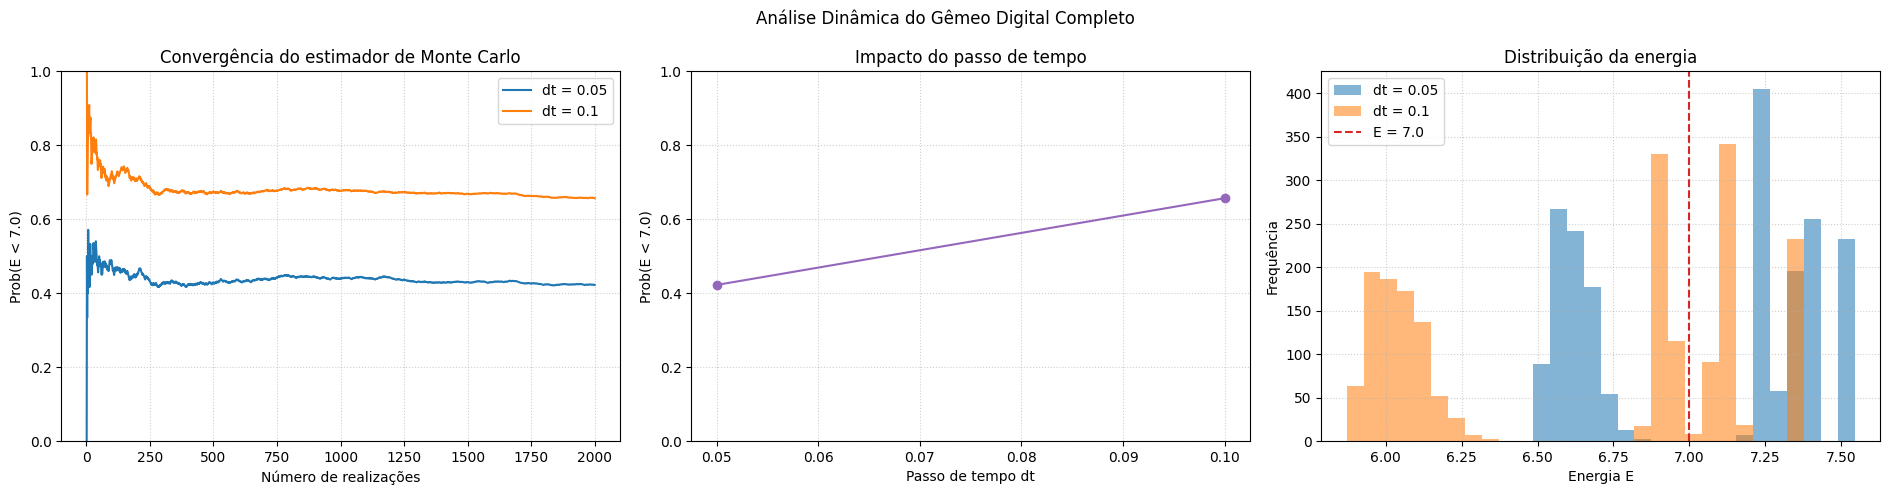

{0.05: {'energias': array([7.20836222, 6.6488772 , 7.52632565, ..., 7.52592317, 7.5377663 ,
         7.38723045], shape=(2000,)),
  'probabilidades': array([0.        , 0.5       , 0.33333333, ..., 0.42292292, 0.42271136,
         0.4225    ], shape=(2000,)),
  'probabilidade_final': 0.4225},
 0.1: {'energias': array([6.86766483, 6.08253059, 7.33134994, ..., 7.33071256, 7.34980568,
         7.12506408], shape=(2000,)),
  'probabilidades': array([1.        , 1.        , 0.66666667, ..., 0.65765766, 0.65732866,
         0.657     ], shape=(2000,)),
  'probabilidade_final': 0.657}}

In [ ]:
analise_falhas.executar_monte_carlo_dinamico(p_O=0.35, f_obs=5, N=2000, plot=True);

#### Aproximação do comportamento da potência através da Interpolação e Regressão

O objetivo dessa seção é reconstruir a curva contínua do funcional de potência através dos instantes de tempo conhecidos com passo $dt = 0.05 s$ dentro do intervalo $T:[0,4]$, em cenários de sinal limpo ou com ruído, através tanto da interpolação linear e por spline cúbica.

#### Interpolação linear e Cúbica

O método da interpolação tem como intuíto criar uma curva que obrigatoriamente intercepta todos os pontos discretos. Pela interpolação linear, isso é feito conectando os pontos em série através de polinômios de primeiro grau localmente, que resulta em função contínua, porém com descontinuidade na primeira derivada sobre os pontos base. A interpolação por spline cúbica por sua vez adota polinômios de terceiro grau, que gera uma função contínua e com derivadas de primeira e segunda ordem contínuas. Contudo, esse método não é muito eficaz quando há ruído, pois a aproximação dos dados vai tratar picos de ruído como parte da curva a ser encontrada.

#### Regressão Polinomial por Mínimos Quadrados

O método da regressão polinomial tenta gerar uma curva através de um polinômio de grau $m$, encontrada realizando o método dos mínimos quadrados. Como, pelo método dos mínimos quadrados, a curva pode não estar sobre os pontos discretos, nós calculamos a função erro:

$$  \mathbb{e} = \sqrt{\int_{t_i}^{t_f} ( P_{\text{aprox}}(t_j) - P_{\text{full}}(t_j))^2 dt}$$

É possível notar através dos resultados abaixo, que o método dos mínimos quadrados lida bem melhor com situações de ruído, enquanto a interpolação sofre de overfitting nesse caso. Também é possível analisar que para $ m < 6 $, o polinômio sofre underfitting, enquanto para $ m > 11 $ demonstra overfitting.


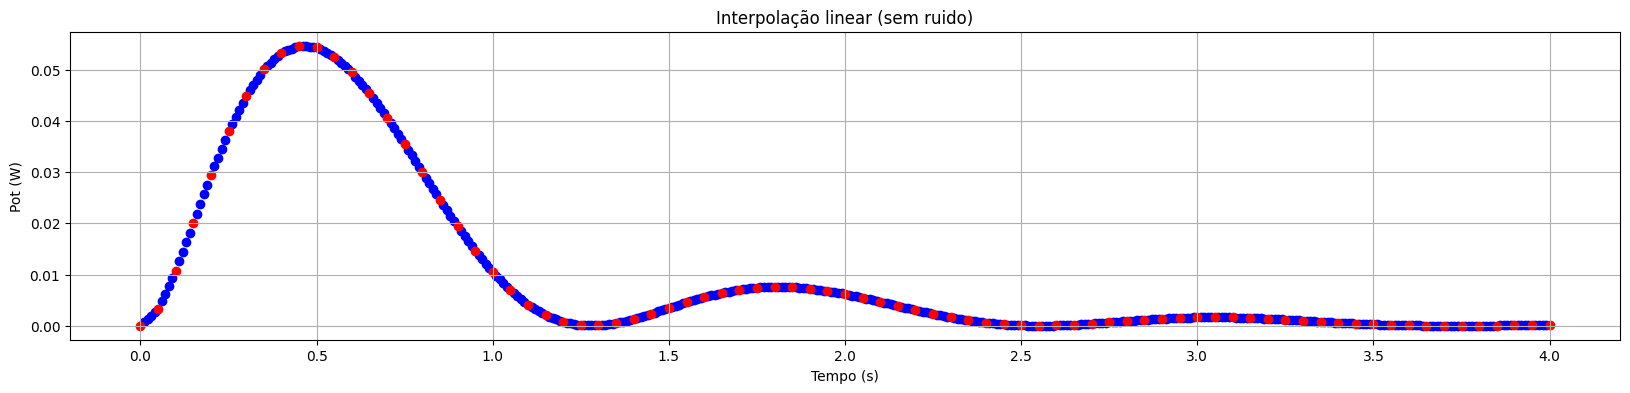

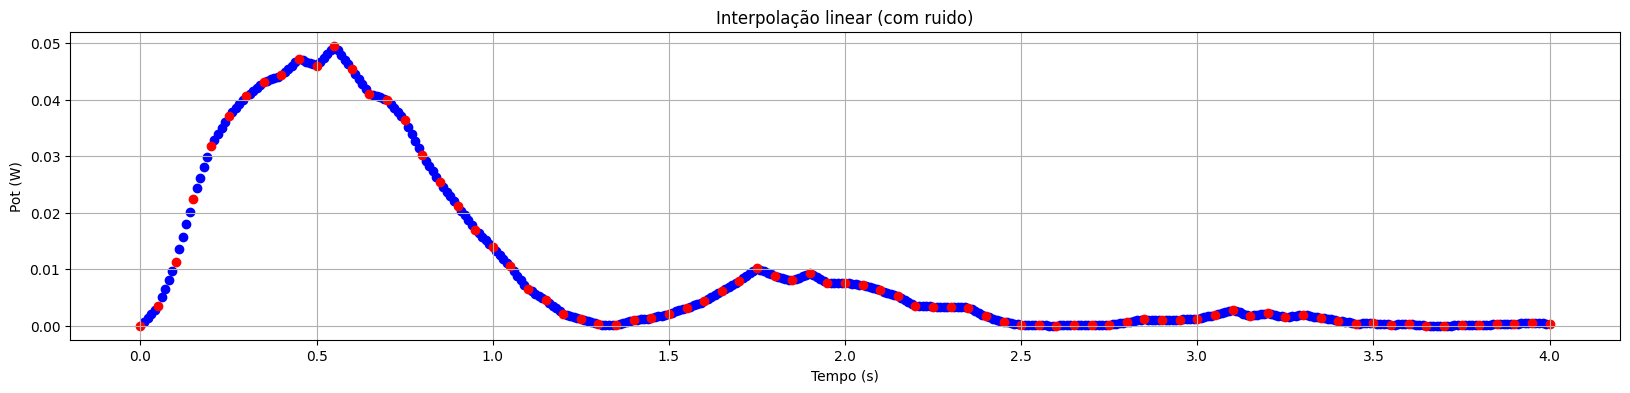

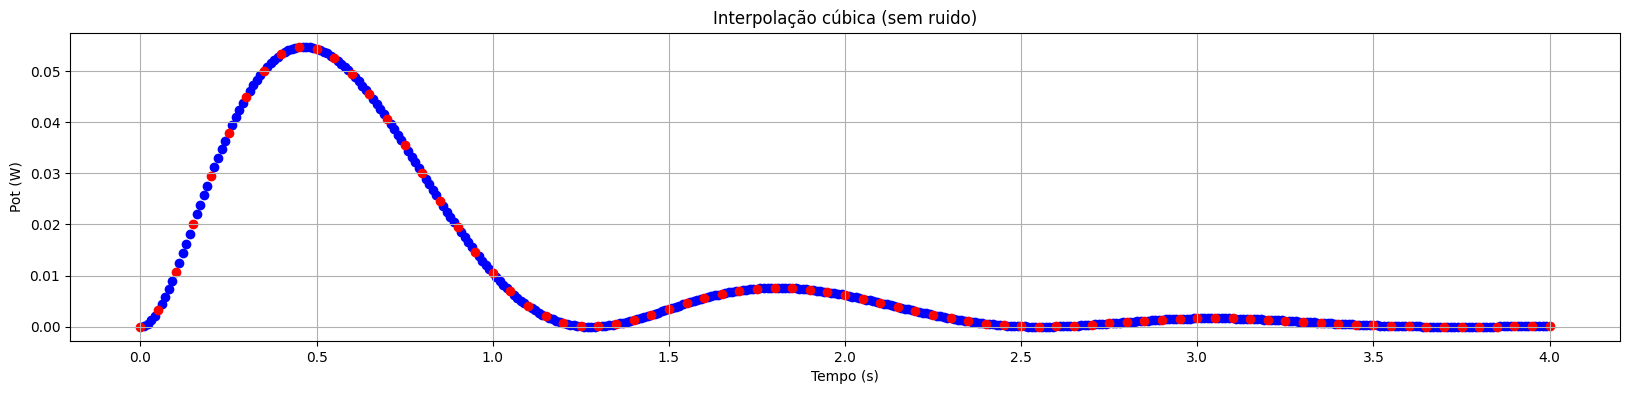

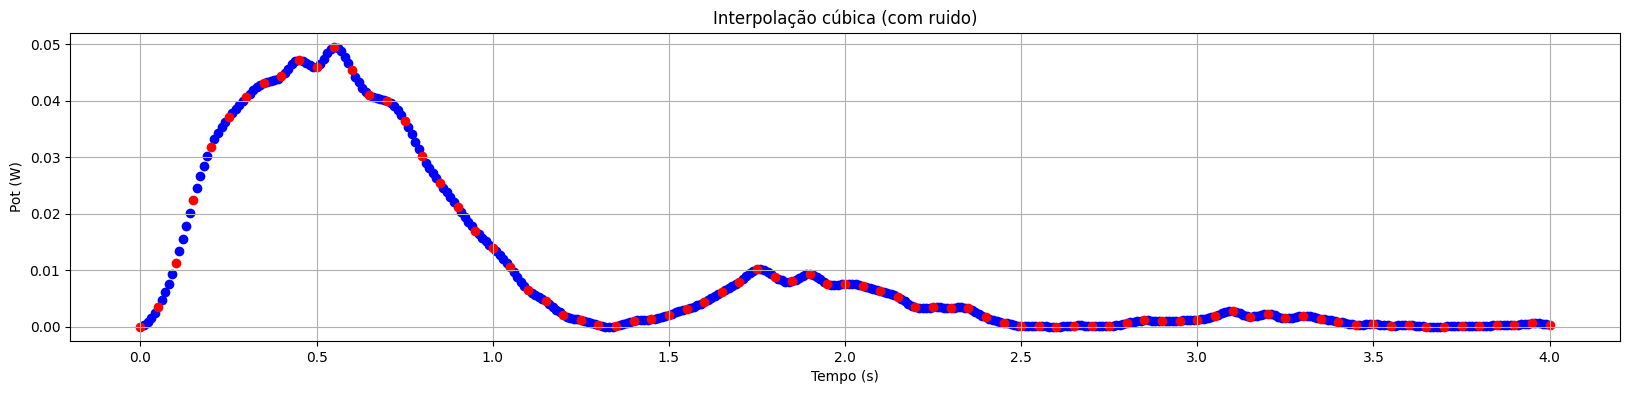

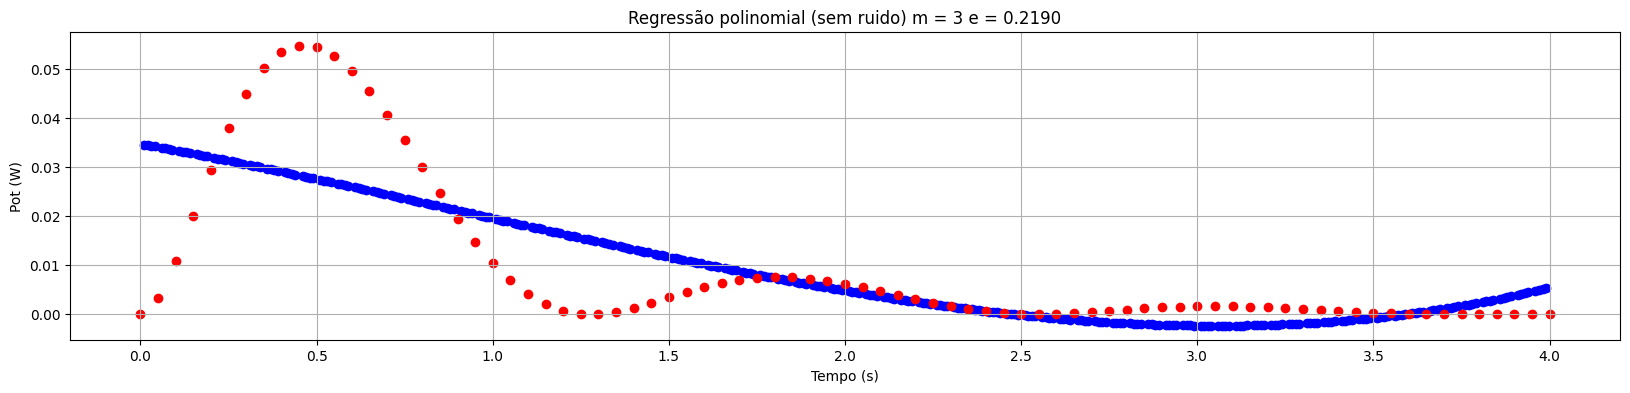

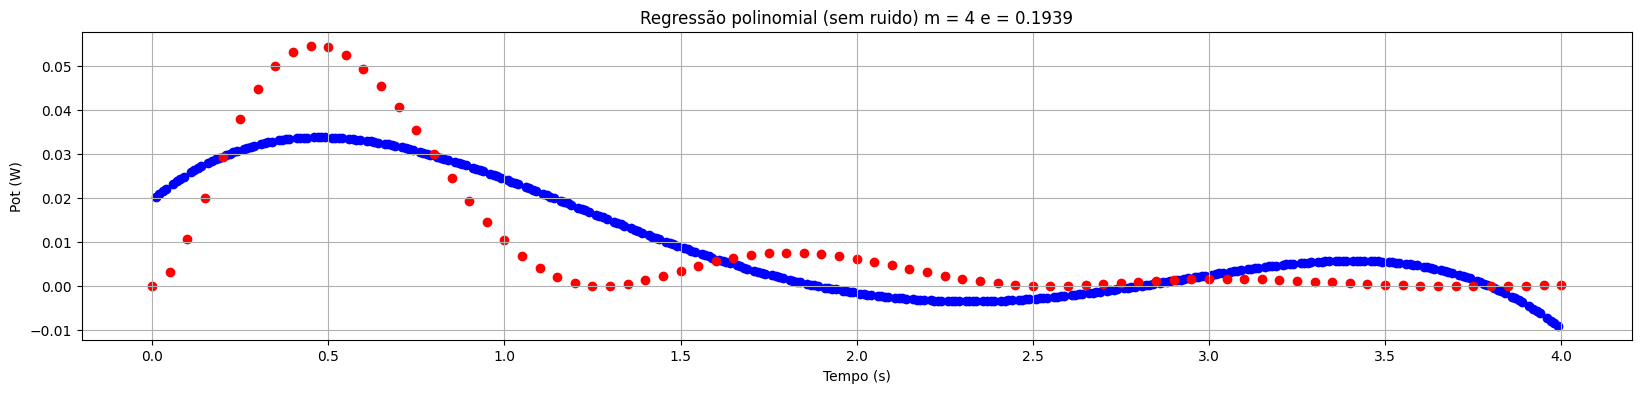

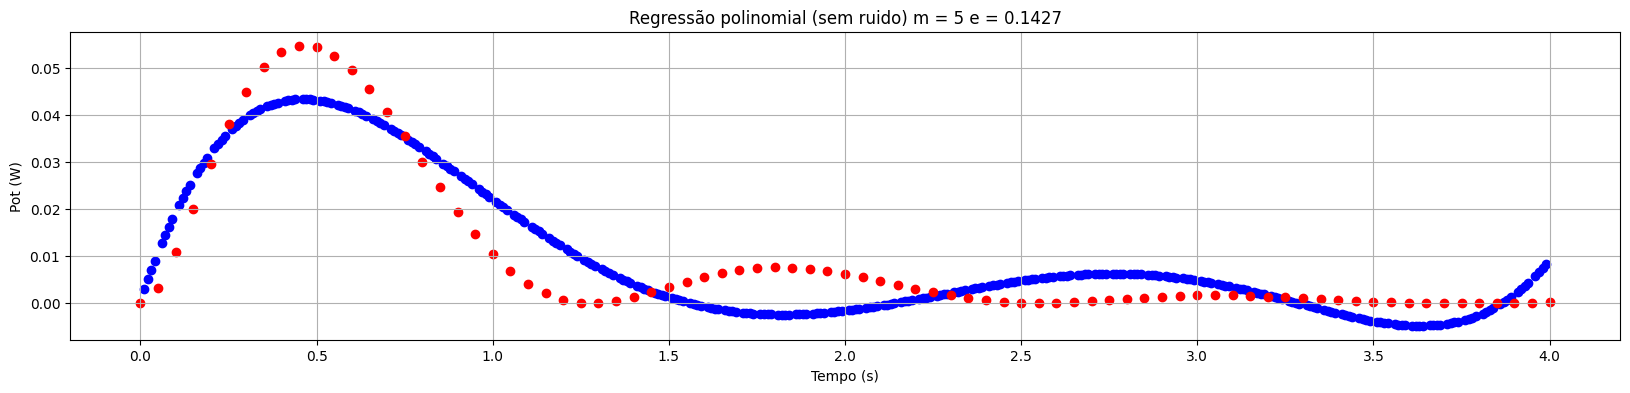

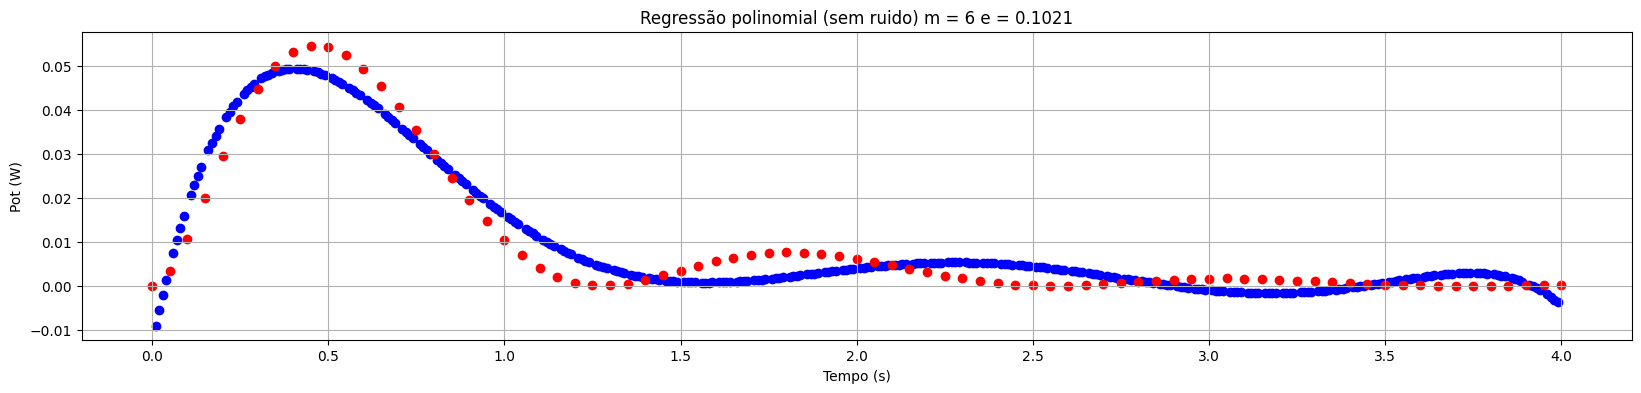

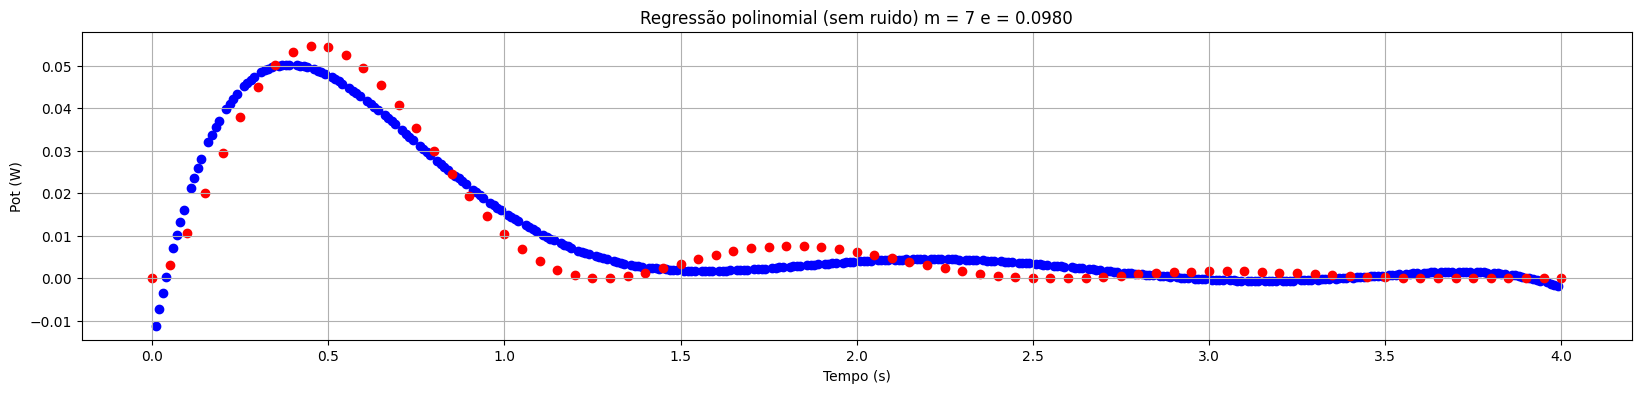

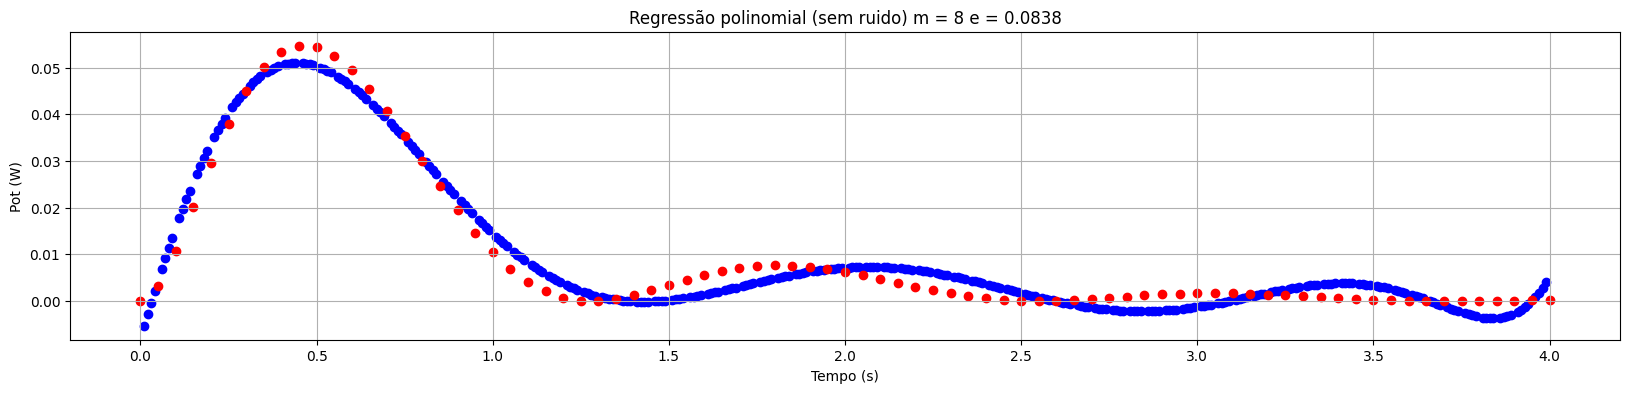

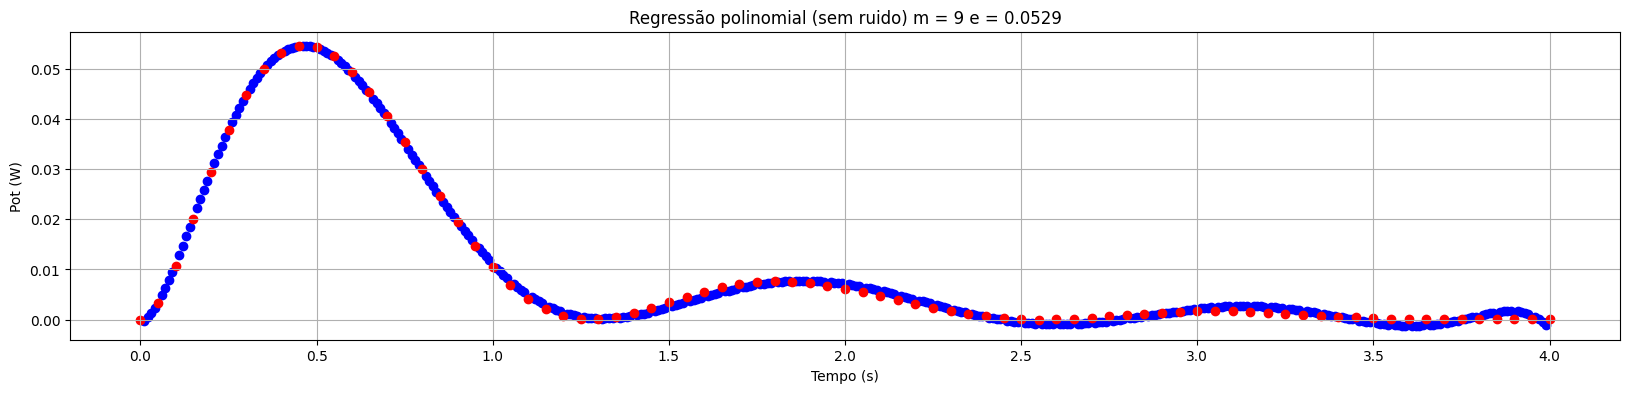

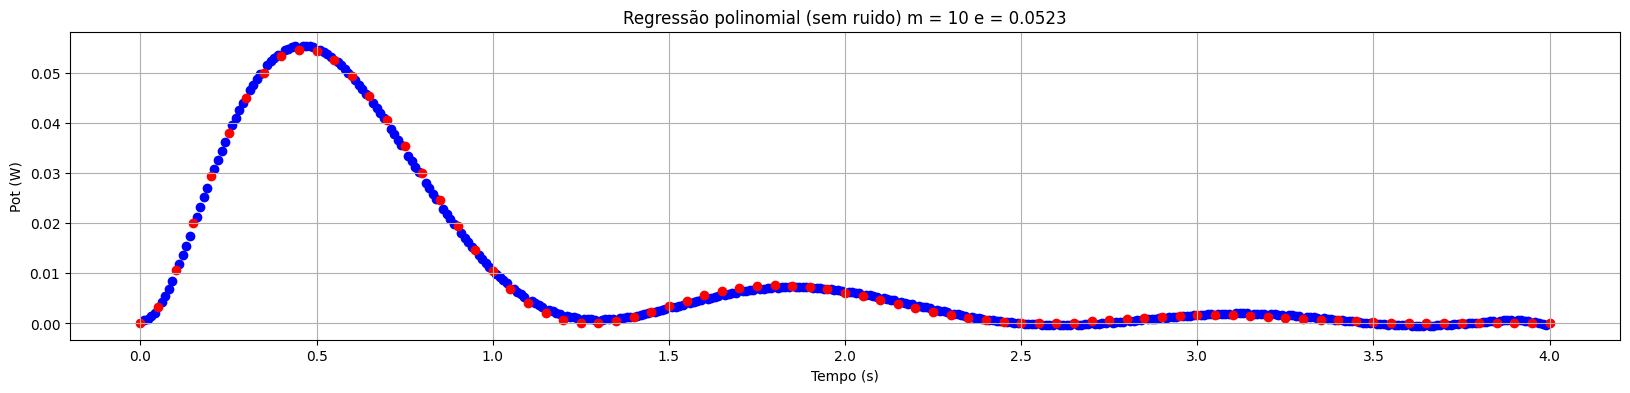

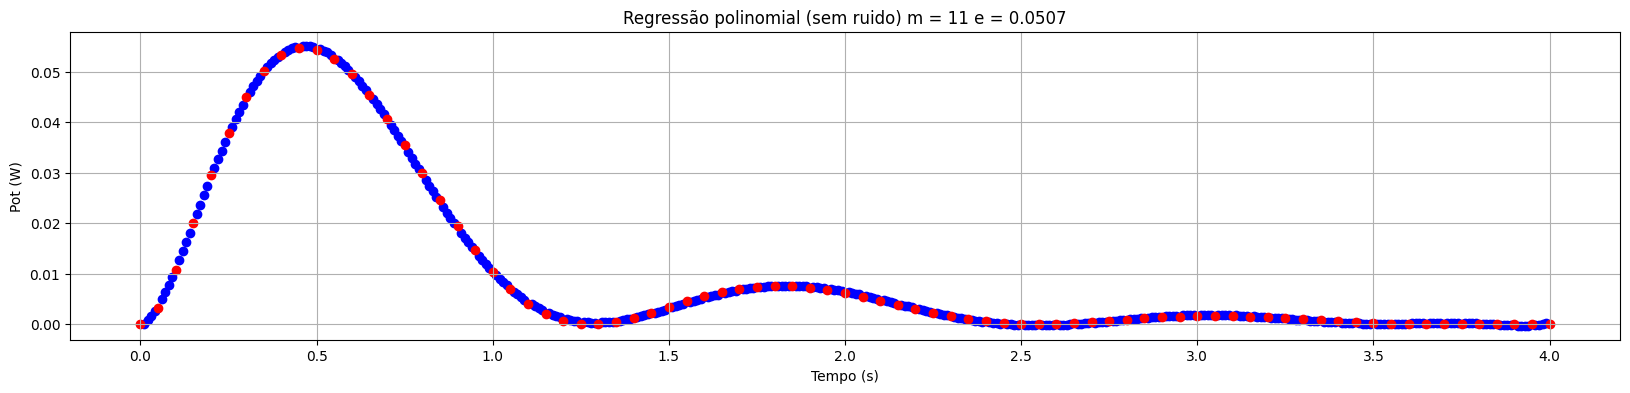

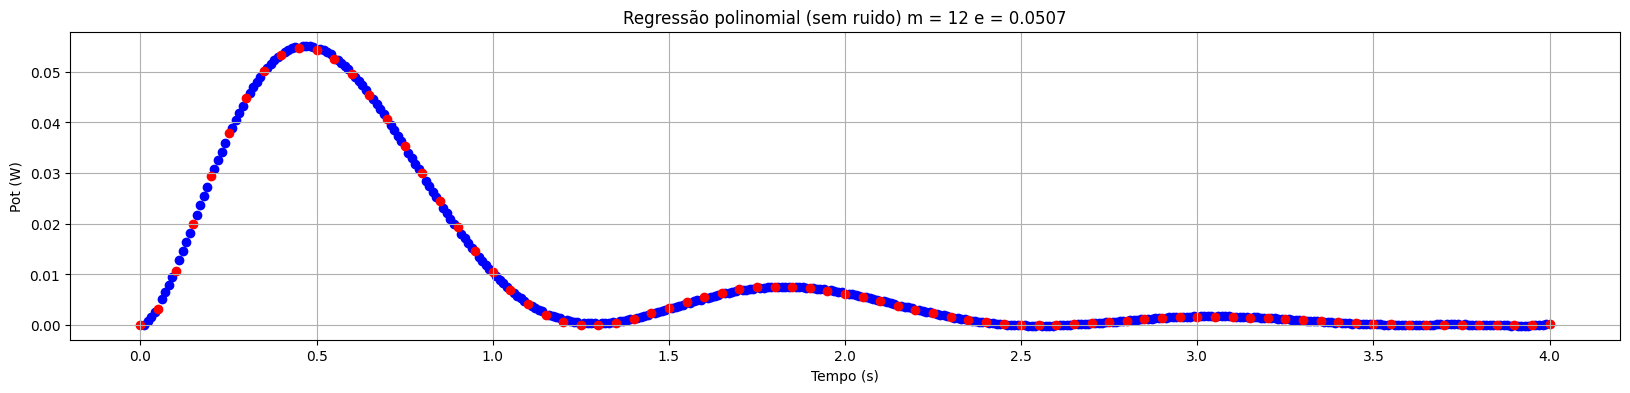

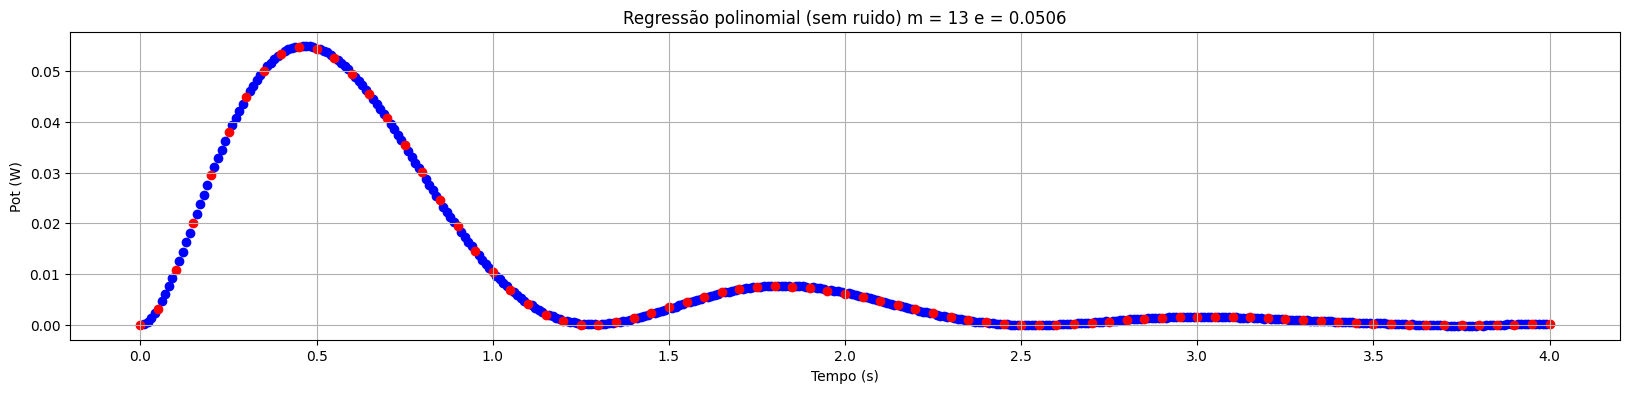

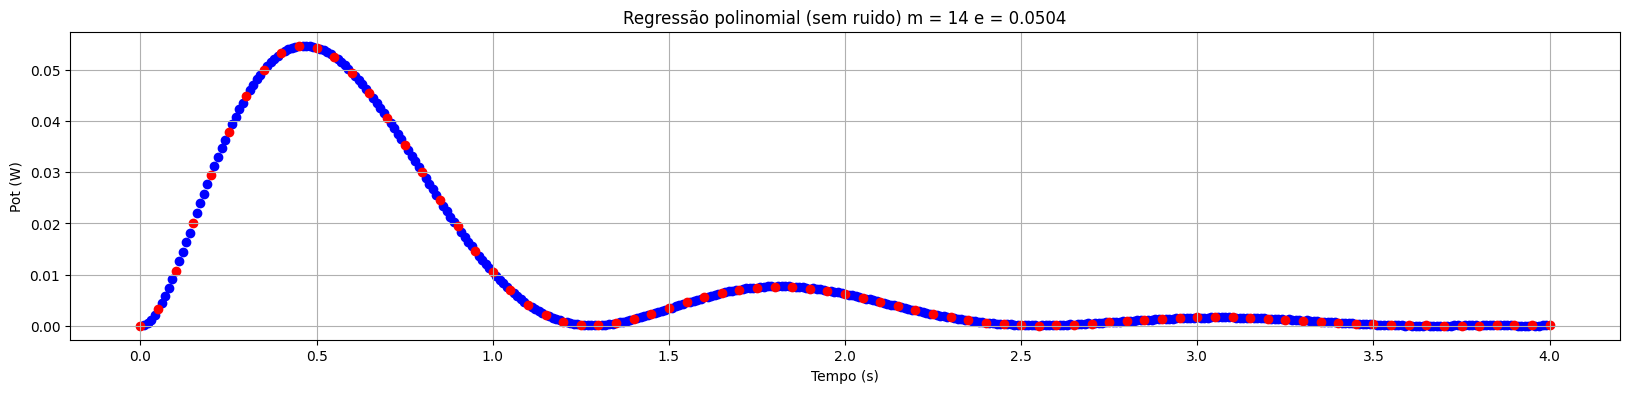

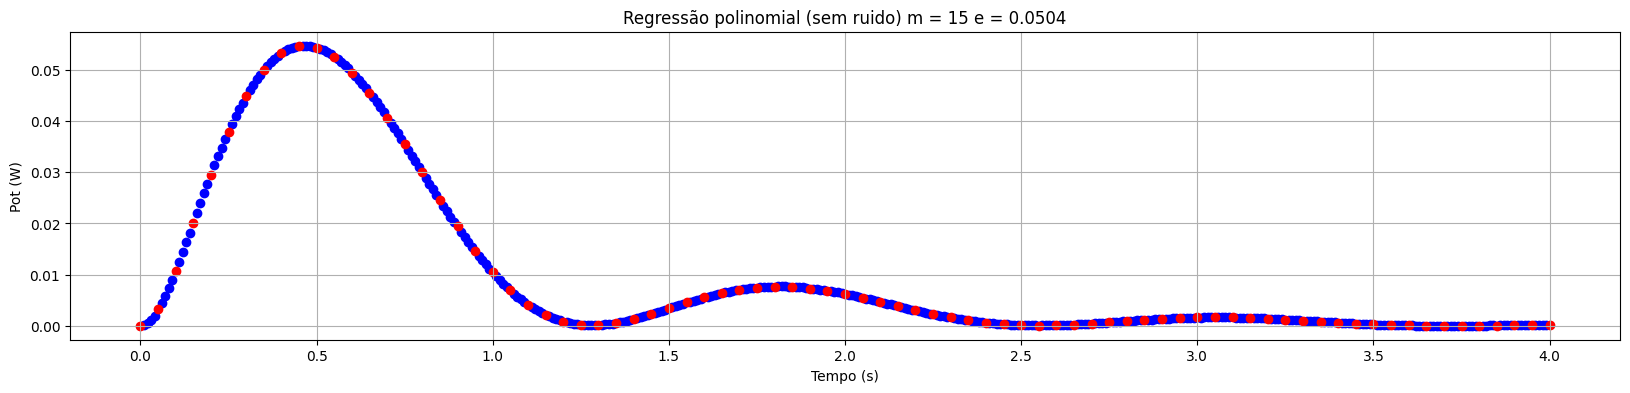

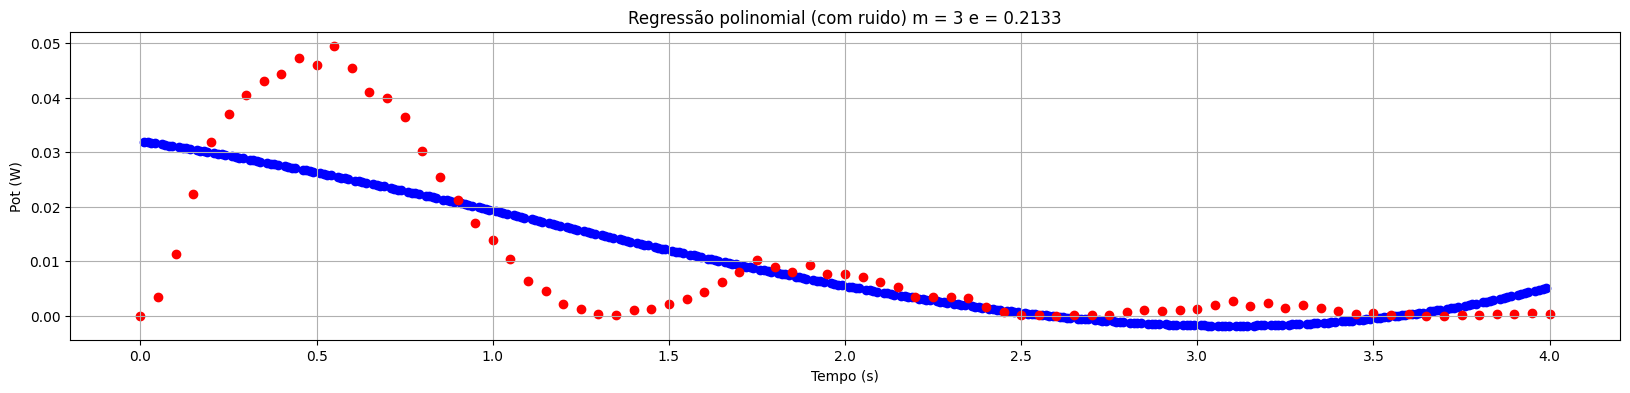

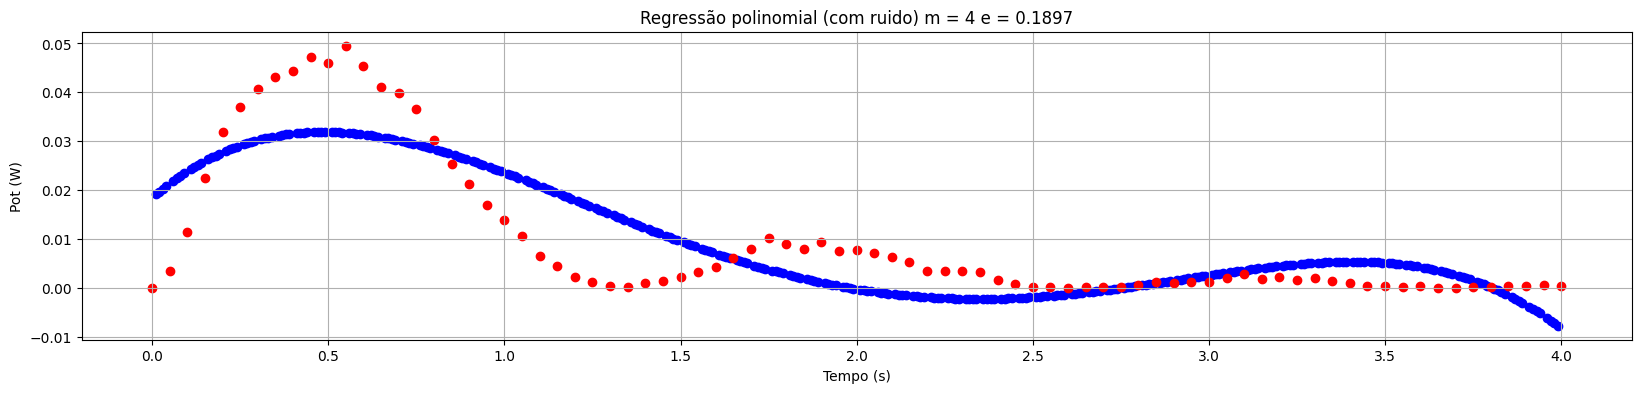

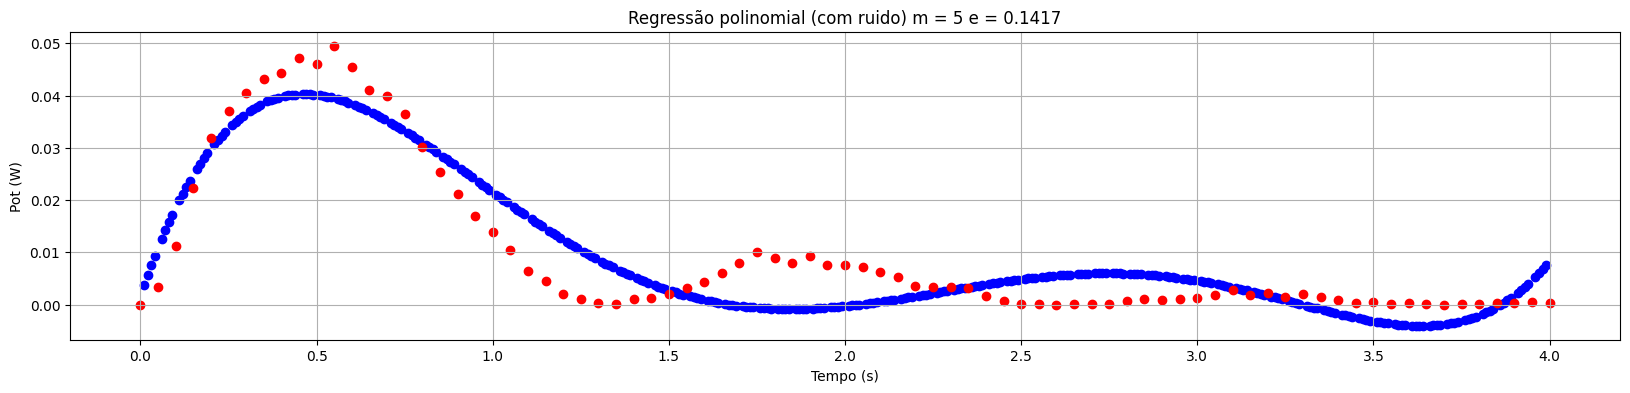

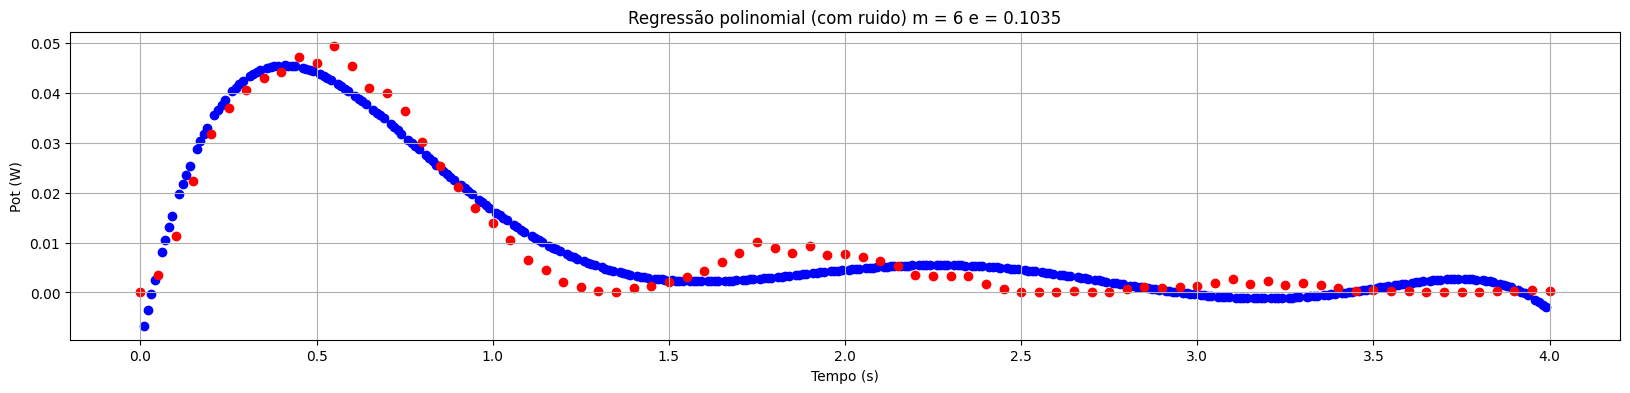

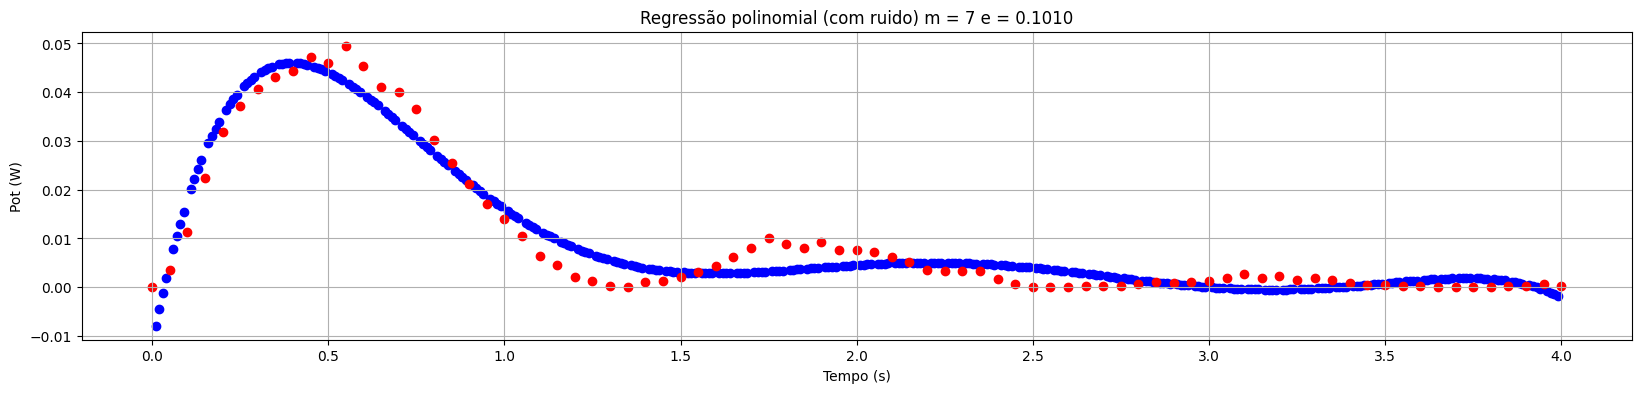

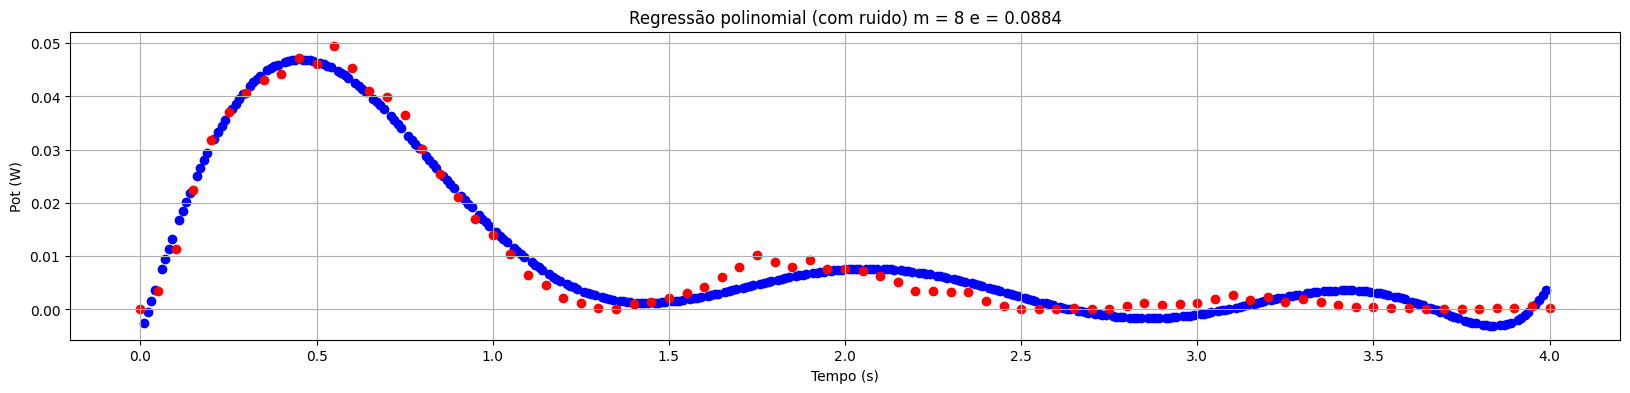

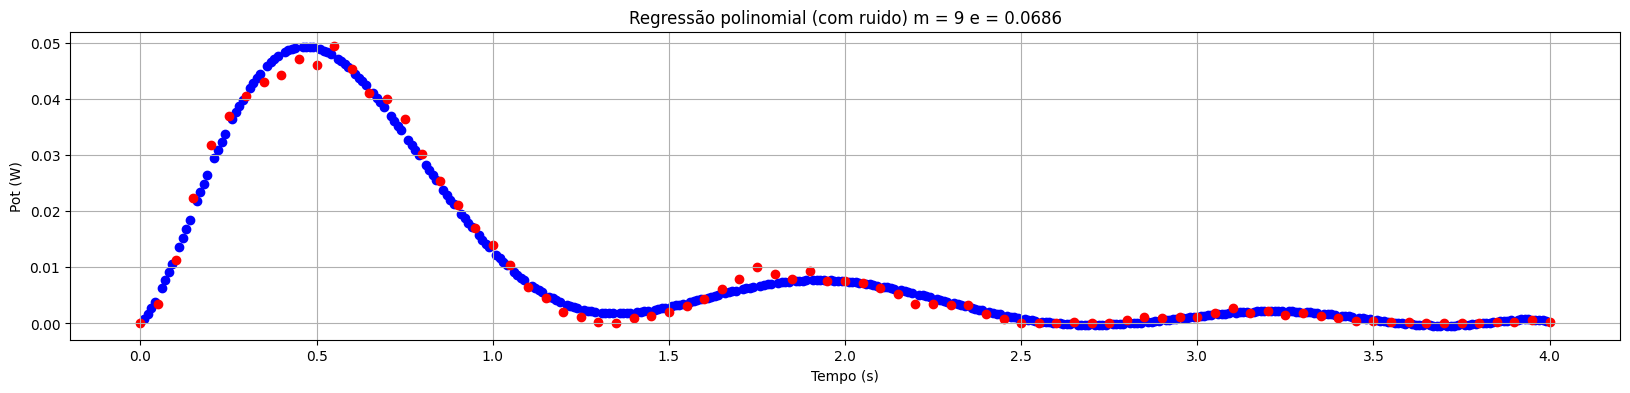

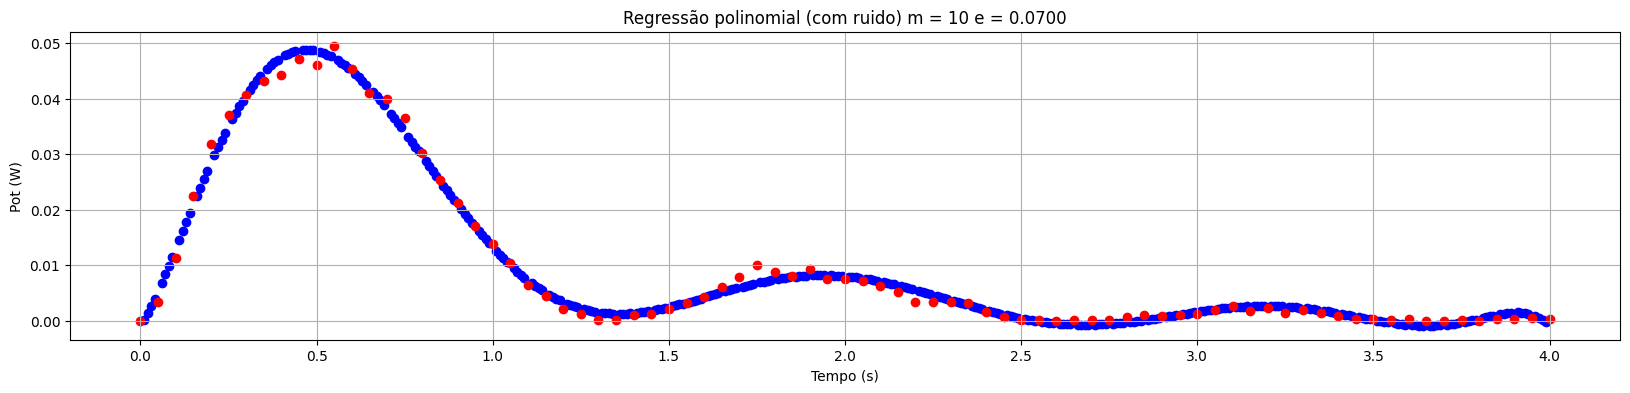

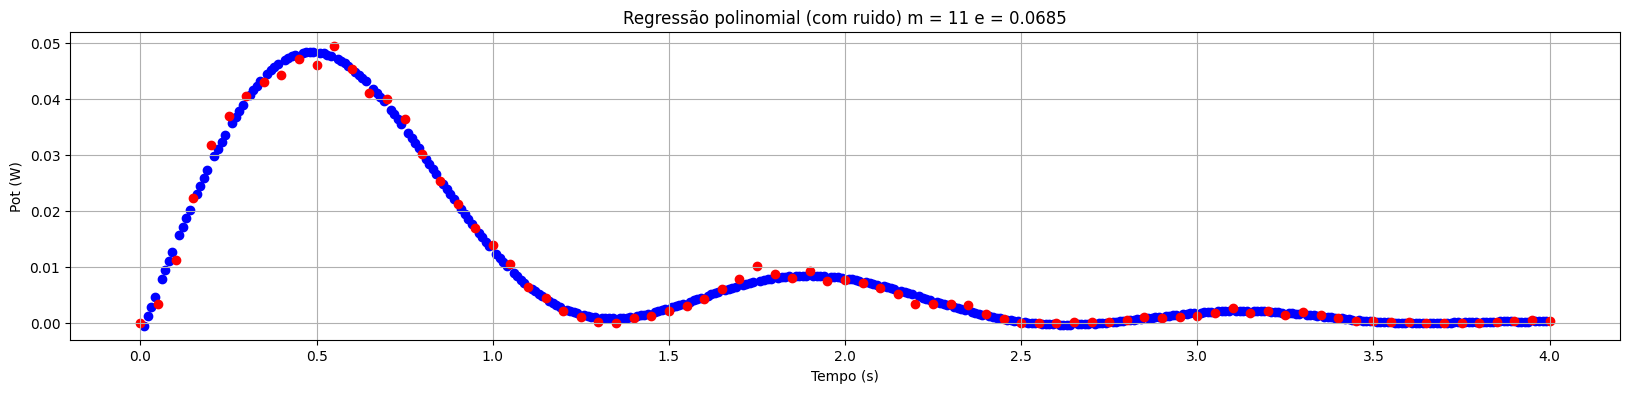

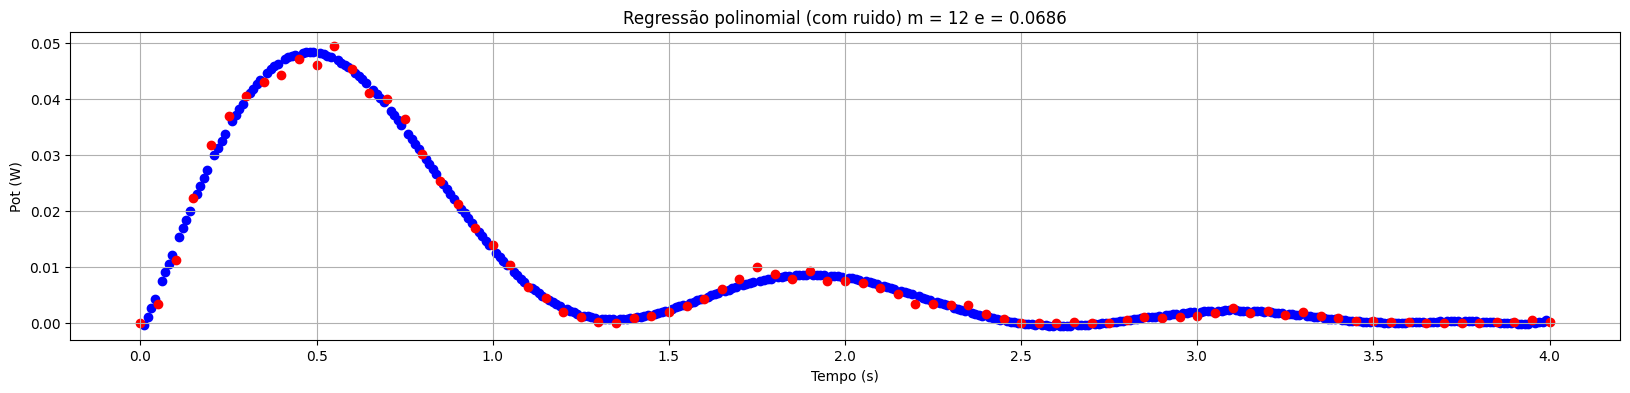

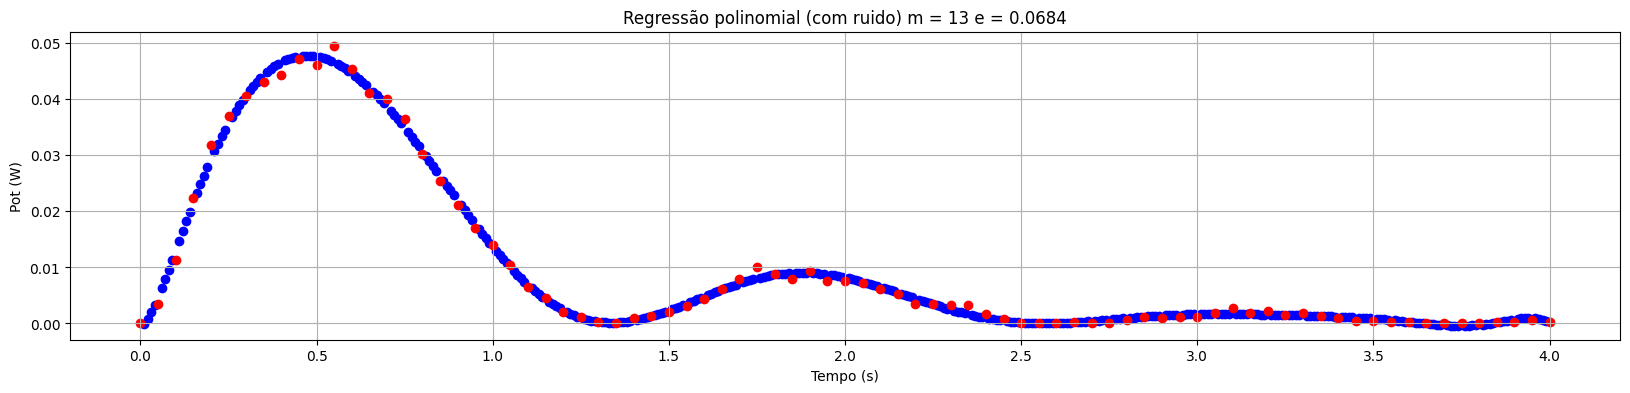

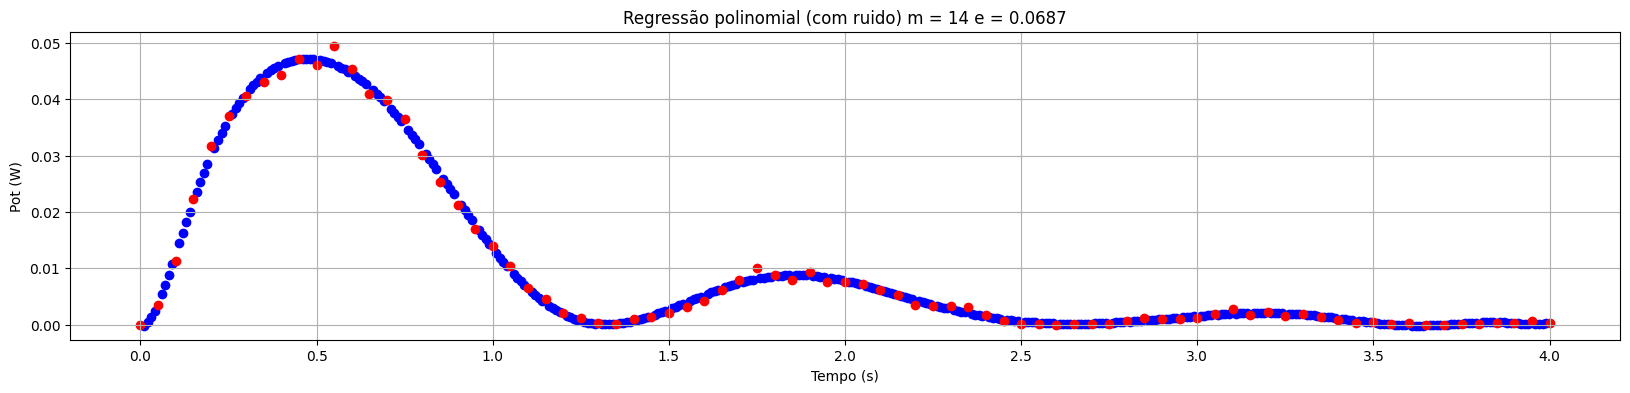

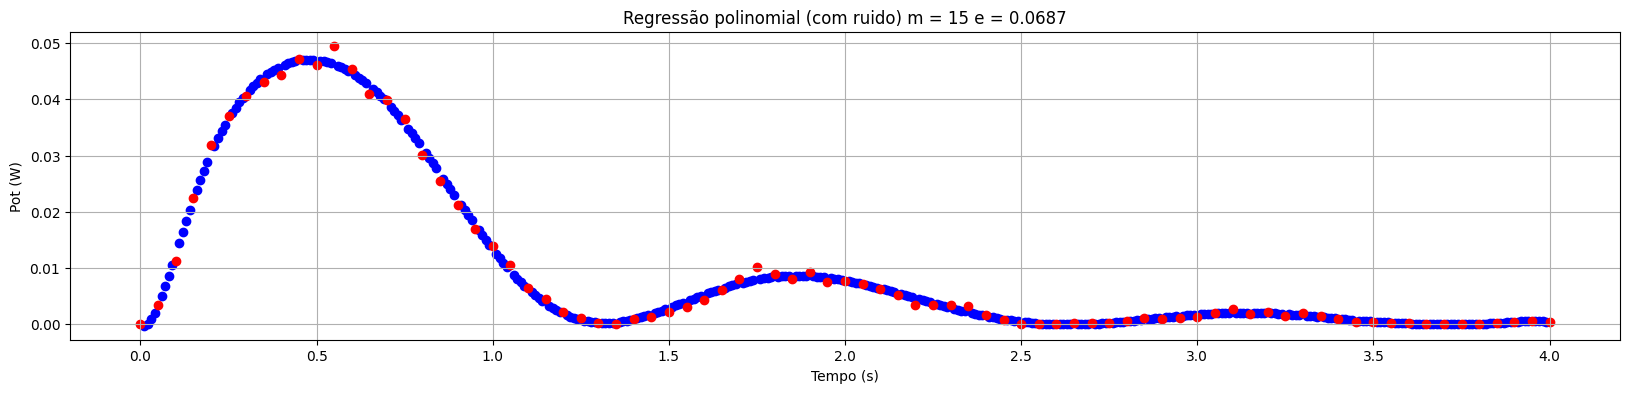

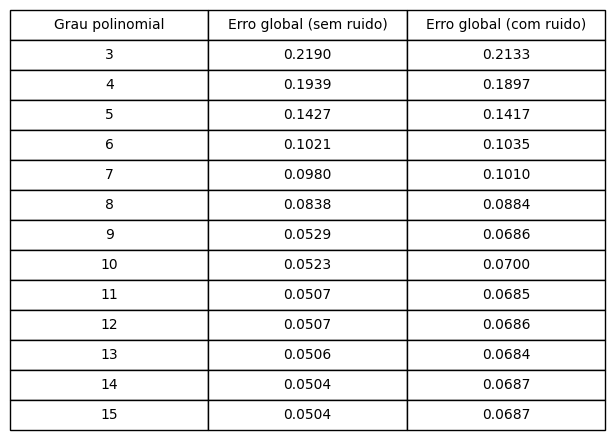

In [11]:
aprox = analise_falhas.aprox_dados(config_mh)
aprox.run()

#### Análise da sensibilidade dos parâmetros do Gêmeo Digital

Nesse problema, o objetivo é analisar o impacto da variação da temperatura ($T_C$) e da largura do canal ($H$) sobre as saídas do Gêmeo Digital, como Potência $E$, Vazão $q_{\text{inlet}}$ e Volume $V(t_f)$. Primeiro é feita uma varredura fixando a temperatura e simulando o sistema com 50 valores de %H%, depois é feito o mesmo fixando a altura e simulando o sistema com 50 temperaturas. Com o comportamento base conhecido, teremos de resolver derivadas parciais numéricamente e analiticamente usando duas implementações do método das diferenças finitas, o forward, que consiste em apenas testar uma direção para aproximar a derivada, desta forma:

$$\frac{\partial F}{\partial x} \approx \frac{F(x + \Delta x) - F(x)}{\Delta x}$$

Enquanto o método das diferenças finitas centrada testa um deslocamento $dx$ em duas direções opostas (diminuindo o erro do método):

$$\frac{\partial F}{\partial x} \approx \frac{F(x + \Delta x) - F(x - \Delta x)}{2\Delta x}$$

A solução analítica utiliza a lei de Poiseuille para determinar:

$$\frac{\partial F}{\partial H} = 4 \cdot \left(\frac{F}{H^4}\right) \cdot H^3 = \frac{4 \cdot F}{H}$$

$$\frac{\partial F}{\partial T_C} = \left(-\frac{F}{\mu}\right) \cdot \frac{d\mu}{dT_C} = -F \cdot \left( \frac{\frac{d\mu}{dT_C}}{\mu} \right)$$

Com esses três métodos, primeiramente fixa a temperatura e usa novamente 50 valores $H$, para cada valor há duas simulações, $ H + \Delta H$ e $H - \Delta H$, esse resultado é usado para calcular a sensibilidade de $H$ ($\partial / \partial H$) através dos três métodos discutidos. Após isso, o exato mesmo processo é realizado sobre a temperatura $T_c$ e sua sensibilidade $T$ ($\partial / \partial T$) é calculada pelos três métodos.

O erro é calculado assumindo que a solução analítica possua 0% de erro, logo calcula-se a diferença porcentual entre os resultados dela e dos métodos de aproximação.



  ANÁLISE DE SENSIBILIDADE — GÊMEO DIGITAL MICROFLUÍDICO
  Parâmetros nominais : Tc = 25.0 °C,  H = 1000 µm
  Perturbações        : ΔTc = 0.001,  ΔH = 1e-06
  Pontos na varredura : 50  (cada eixo)
  Viscosidade nominal : μ(Tc_nom) = 9.0449e-04 Pa·s

[1/5] Varredura de comportamento F(Tc) com H fixo…
    Tc =    0.0 °C → E = 2.840e-02 W | q = 7.611e-06 m³/s | V = 2.751e-11 m³
    Tc =   45.9 °C → E = 1.391e-02 W | q = 9.245e-06 m³/s | V = 3.215e-11 m³
    Tc =   96.9 °C → E = 7.376e-03 W | q = 9.769e-06 m³/s | V = 3.360e-11 m³
    Tc =  148.0 °C → E = 4.509e-03 W | q = 9.977e-06 m³/s | V = 3.417e-11 m³
    Tc =  199.0 °C → E = 3.028e-03 W | q = 1.008e-05 m³/s | V = 3.445e-11 m³
    Tc =  250.0 °C → E = 2.169e-03 W | q = 1.014e-05 m³/s | V = 3.461e-11 m³

[2/5] Varredura de comportamento F(H) com Tc fixo…
    H =   500.0 µm → E = 2.111e-02 W | q = 2.309e-06 m³/s | V = 1.027e-11 m³
    H =   683.7 µm → E = 3.461e-02 W | q = 5.527e-06 m³/s | V = 2.124e-11 m³
    H =   887.8 µm → E = 2.562e

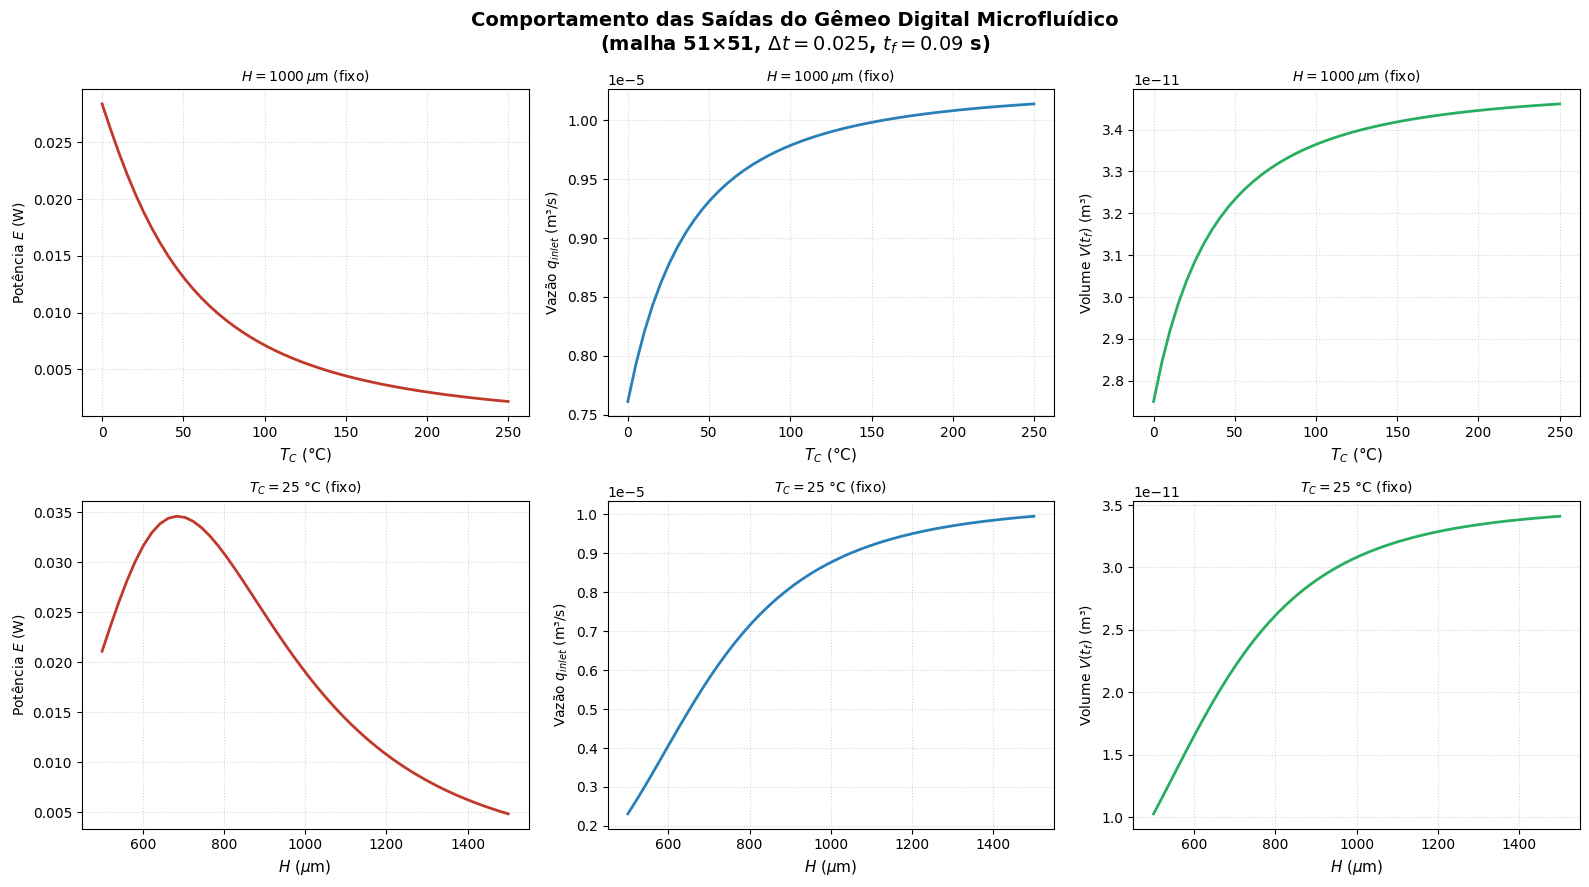

  → Salvo: sens_comportamento.png

[3/5] Calculando ∂F/∂H (Forward + Centrada + Analítica)…
    H =   500.0 µm  [f(H±ΔH) calculados]
    H =   683.7 µm  [f(H±ΔH) calculados]
    H =   887.8 µm  [f(H±ΔH) calculados]
    H =  1091.8 µm  [f(H±ΔH) calculados]
    H =  1295.9 µm  [f(H±ΔH) calculados]
    H =  1500.0 µm  [f(H±ΔH) calculados]

[4/5] Calculando ∂F/∂Tc (Forward + Centrada + Analítica)…
    Tc =    0.0 °C  [f(Tc±ΔTc) calculados]
    Tc =   45.9 °C  [f(Tc±ΔTc) calculados]
    Tc =   96.9 °C  [f(Tc±ΔTc) calculados]
    Tc =  148.0 °C  [f(Tc±ΔTc) calculados]
    Tc =  199.0 °C  [f(Tc±ΔTc) calculados]
    Tc =  250.0 °C  [f(Tc±ΔTc) calculados]

  SENSIBILIDADES NO PONTO NOMINAL  (H = 1000 µm, Tc = 25 °C)
  ---------------------------------------------------------------------
  Derivada                  Forward           Centrada          Analítica
  ---------------------------------------------------------------------
  dE/dH                 -5.4216e+01        -5.4273e+01         7.

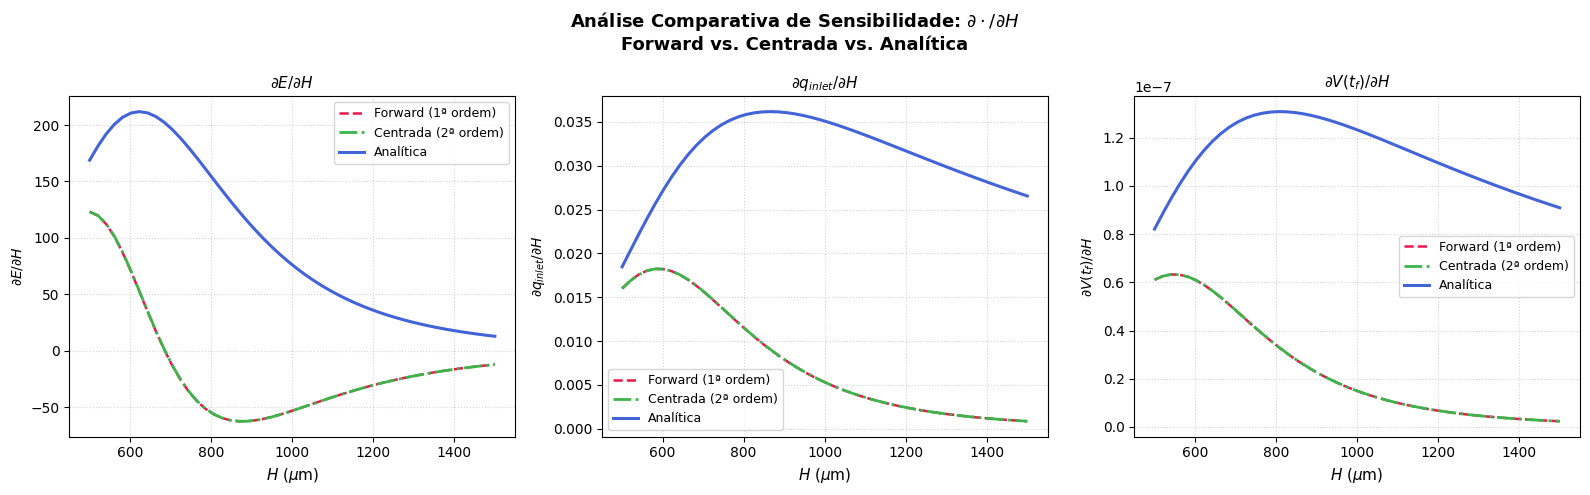

  → Salvo: sens_derivadas_H.png


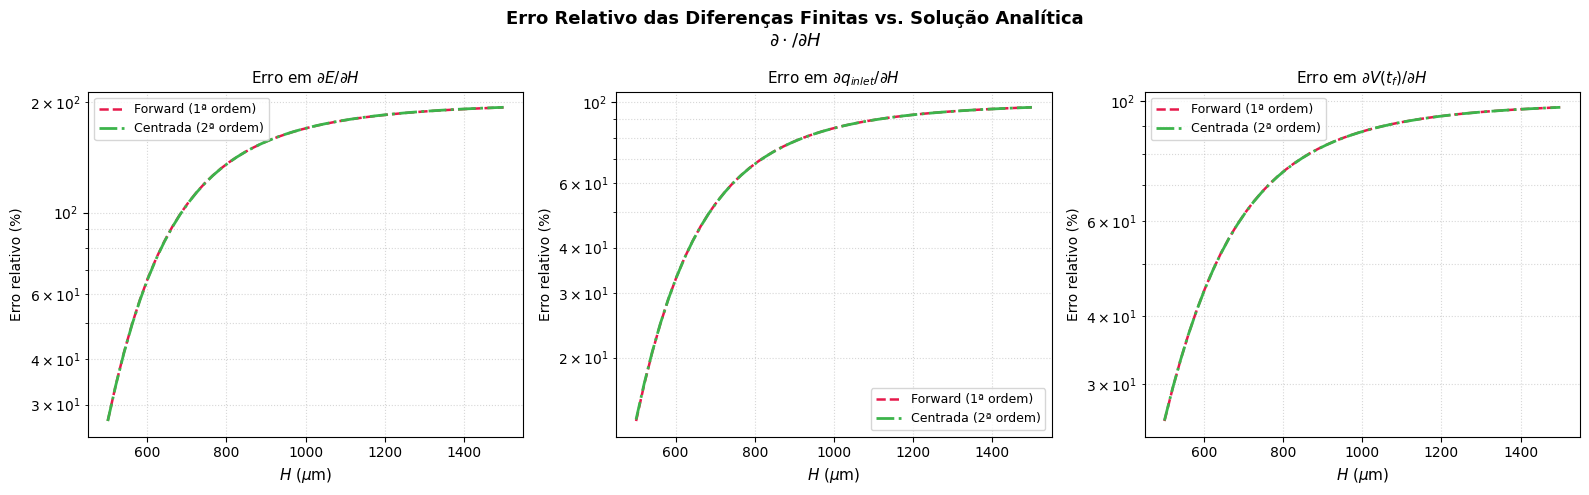

  → Salvo: sens_erro_H.png


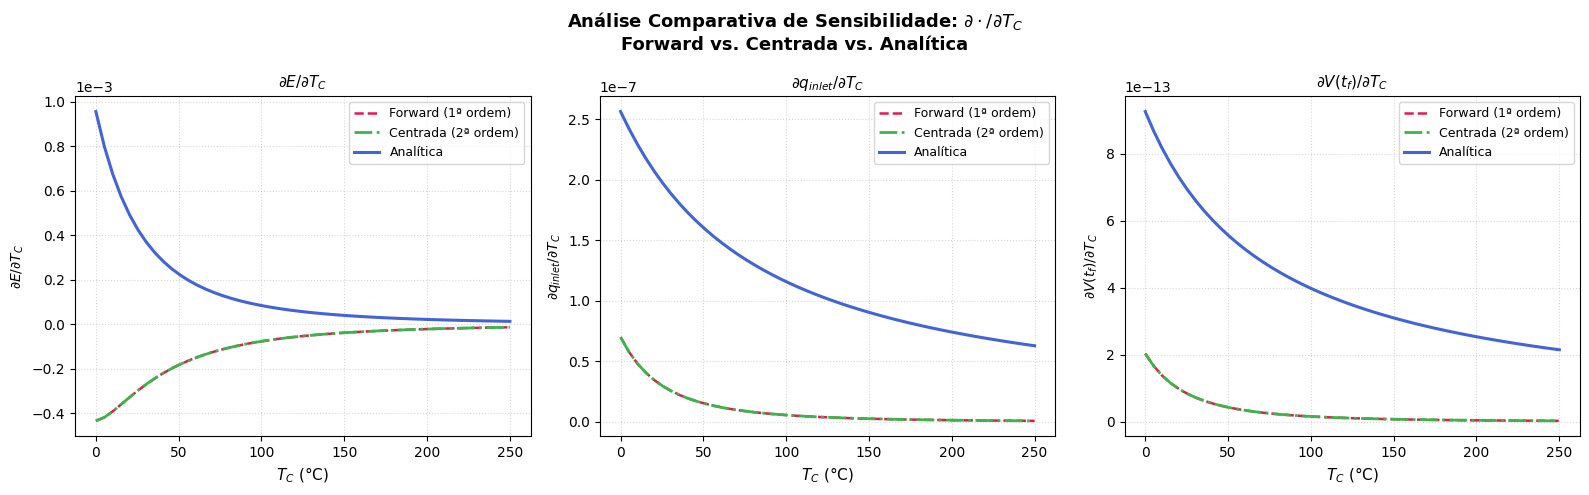

  → Salvo: sens_derivadas_Tc.png


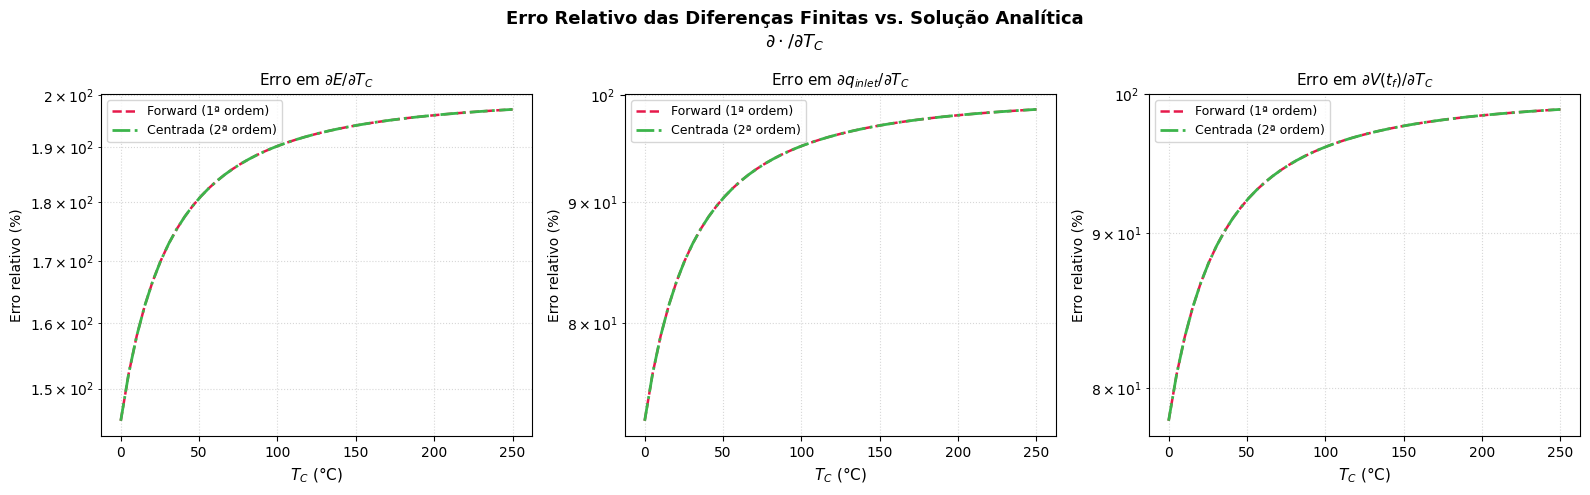

  → Salvo: sens_erro_Tc.png

✓ Análise concluída em 17.5 s.
  Arquivos gerados:
    • sens_comportamento.png  — F(Tc) e F(H) para E, q, V
    • sens_derivadas_H.png    — ∂F/∂H: Forward / Centrada / Analítica
    • sens_erro_H.png         — Erro relativo ∂F/∂H vs. analítica
    • sens_derivadas_Tc.png   — ∂F/∂Tc: Forward / Centrada / Analítica
    • sens_erro_Tc.png        — Erro relativo ∂F/∂Tc vs. analítica


In [7]:
sensitivity_analysis.prob3()

##### Determinar valor ótimo de ajuste para largura H com restrição de energia

Nesse problema, nosso objetivo é determinar a largura H ideal para os canais dentro da limitação de energia $E = 7.5$. Para isso, nós vamos resolver um problema de busca de raiz da forma:
$$F(H) = E(H) - E_{\text{target}}$$

Onde estamos buscando $F(H) = 0$. Para isso, nós vamos utilizar o método de Newton-Raphson, que é um método iterativo que busca a raiz da função através do uso sucessivo de derivadas. O algoritmo tem forma: 

$$H_{k+1} = H_k - \frac{f(H_k)}{f'(H_k)}$$

onde:

$$f'(H_k) = \frac{\partial E}{\partial H}(H_k)$$

No caso da nossa implementação, nós começamos com um $H_k$ arbitrário, dentro dos valores físicamente possíveis, e esse $H_k$ é usado para resolver o sistema e calcular a energia $E$ de forma convencional, com esse resultado, temos uma iteração $f(H_1)$, para calcular a derivada f'(H_1) nós utilizamos o método das diferenças finitas, visto nos exercícios anteriores, e simulamos o sistema novamente com uma variação pequena $dh$, com isso, podemos calcular $H_2$ e subsequentemente $f(H_2), assim em diante até que o erro resídual seja menor que a tolerância definida. Vale notar que essa implementação tem uma limitação de passo de no máximo 20% do valor atual, para impedir mudanças muito grandes e repentinas que poderiam causar divergência.

PROBLEMA 2: OTIMIZAÇÃO VIA NEWTON-RAPHSON NUMÉRICO
  Iniciando: Alvo = 7.5, H inicial = 1000.0 µm, Tc = 25.0 °C
t_adim[0], t_adim[-1]:
0.0 1885.6180831641266
np.min(pot_adim), np.max(pot_adim):
0.0 8.078143190339718
E_adim_integral:
5834.235239834565
Primeira potência diferente de zero:
tempo = 0.025
pot = 0.001667843219889792

  [DIAGNÓSTICO] Valores Adimensionais na Iteração 0:
    -> energia_total_adim = 5834.2352
    -> vazao_inlet_adim = 2.9766
    -> potencia_inlet_adim = 37.2077
  [Info] Otimizando ativamente para o funcional: 'energia_total_adim'

    Iter 00: H = 1000.000 µm | Valor Atual = 5834.2352 | Erro =  5.83e+03
t_adim[0], t_adim[-1]:
0.0 1885.6180831641266
np.min(pot_adim), np.max(pot_adim):
0.0 8.05564609048676
E_adim_integral:
5816.6821964021365
Primeira potência diferente de zero:
tempo = 0.025
pot = 0.0016620406291373766
t_adim[0], t_adim[-1]:
0.0 1885.6180831641266
np.min(pot_adim), np.max(pot_adim):
0.0 4.576085649595534
E_adim_integral:
3207.8285297051875
Primei

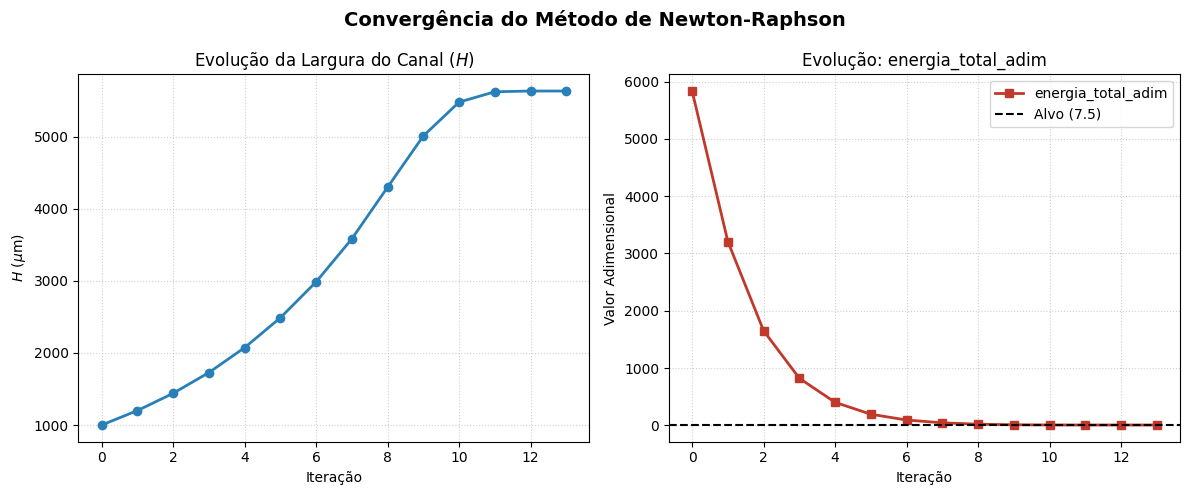

In [10]:
solver_p2 = P2_PARTE_3_GD.P2_3_GD(config_mh)
solver_p2.resolver_P2(E_target=7.5, H0=1000.0e-6, Tc=25.0);